In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.fft import fft, ifft, fftfreq
from scipy.interpolate import CubicSpline
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error, r2_score
from xgboost import XGBRegressor

plt.style.use('seaborn-v0_8-muted')
%matplotlib inline

df = pd.read_csv('SPY_1min_firstratedata.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['date'] = df['timestamp'].dt.date

# Filter for RTH (Regular Trading Hours)
df_rth = df.set_index('timestamp').between_time('09:30', '16:00').reset_index()

# Target Engineering: Normalized daily volume share
# v_t / sum(v_t for the whole day)
daily_sum = df_rth.groupby('date')['volume'].transform('sum')
df_rth['vol_proportion'] = df_rth['volume'] / daily_sum

# Time feature: Minutes since market open
df_rth['minute_of_day'] = (df_rth['timestamp'].dt.hour * 60 + df_rth['timestamp'].dt.minute) - 570

print(f"Dataset covers {df_rth['date'].nunique()} trading days.")
df_rth.head()

# # data source: https://firstratedata.com/free-intraday-data
 
# # ── CONFIG ──────────────────────────────────────────────────────────────
# CSV_PATH   = "SPY_1min_firstratedata.csv"        
# TS_COL     = "timestamp"             # ← change if your column is named differently
# TZ_INPUT   = "America/New_York"      # assumes timestamps are already ET

# # 1. LOAD & CLEAN
# df = pd.read_csv('SPY_1min_firstratedata.csv')
# df['timestamp'] = pd.to_datetime(df['timestamp'])
# df['date'] = df['timestamp'].dt.date
# df['time'] = df['timestamp'].dt.time

# # Filter for Regular Trading Hours (RTH)
# df_rth = df.set_index('timestamp').between_time('09:30', '16:00').reset_index()

# # 2. NORMALIZE VOLUME (Proportion of Daily Total)
# # v_t / sum(v_t for day)
# # This gives the "Intraday Volume Profile" (IVP)
# daily_totals = df_rth.groupby('date')['volume'].transform('sum')
# df_rth['vol_proportion'] = df_rth['volume'] / daily_totals

# # 3. COMPUTE TIME-OF-DAY PROFILES (VWTD)
# # Averaging the proportions across all days to find the 'Structural U-Shape'
# vwtd_profile = df_rth.groupby('time')['vol_proportion'].mean().reset_index()
# vwtd_profile.rename(columns={'vol_proportion': 'expected_vol_share'}, inplace=True)

# # Merge back to provide the model with the 'Expected' volume for that minute
# df_rth = df_rth.merge(vwtd_profile, on='time', how='left')

# # 4. 5-MINUTE TICK FEATURE ENGINEERING
# # Resample to 5-minute bars
# df_5m = df_rth.set_index('timestamp').resample('5min').agg({
#     'volume': 'sum',
#     'close': 'last',
#     'high': 'max',
#     'low': 'min'
# }).dropna()

# # Calculate normalized proportion for 5-min bars
# df_5m['date'] = df_5m.index.date
# df_5m['time'] = df_5m.index.time
# daily_total_5m = df_5m.groupby('date')['volume'].transform('sum')
# df_5m['vol_proportion_5m'] = df_5m['volume'] / daily_total_5m

# # 5. FEATURE: ABNORMAL VOLUME (Z-Score of proportion)
# # Identify if current volume is a 'spike' relative to the usual share at this time
# df_5m['expected_share_5m'] = df_5m.groupby('time')['vol_proportion_5m'].transform('mean')
# df_5m['abnormal_vol_signal'] = df_5m['vol_proportion_5m'] / df_5m['expected_share_5m']

# # 6. PERIODICITY DUMMIES (The Tick Anomaly)
# df_5m['is_top_of_hour'] = (df_5m.index.minute == 0).astype(int)
# df_5m['is_30min_mark'] = (df_5m.index.minute % 30 == 0).astype(int)

# # DISPLAY RESULTS
# print("Top 5 Minutes by Volume Share (The U-Shape Peaks):")
# print(vwtd_profile.sort_values(by='expected_vol_share', ascending=False).head(5))

# # Plotting the VWTD Profile
# plt.figure(figsize=(12, 5))
# plt.plot(vwtd_profile['time'].astype(str), vwtd_profile['expected_vol_share'], color='teal')
# plt.title('Volume-Weighted Time-of-Day Profile (SPY 1-Min)')
# plt.ylabel('Proportion of Daily Volume')
# plt.xticks(vwtd_profile['time'].astype(str)[::30], rotation=45)
# plt.grid(True, alpha=0.3)
# plt.show()

Dataset covers 251 trading days.


,timestamp,open,high,low,close,volume,date,vol_proportion,minute_of_day
0,2022-09-30 09:30:00,361.80,362.53,361.79,362.530,631442,2022-09-30,0.006958,0
1,2022-09-30 09:31:00,362.53,362.76,362.17,362.335,260992,2022-09-30,0.002876,1
2,2022-09-30 09:32:00,362.34,362.53,361.79,361.840,189264,2022-09-30,0.002086,2
3,2022-09-30 09:33:00,361.85,362.64,361.85,362.600,192650,2022-09-30,0.002123,3
4,2022-09-30 09:34:00,362.63,362.77,362.37,362.460,187646,2022-09-30,0.002068,4


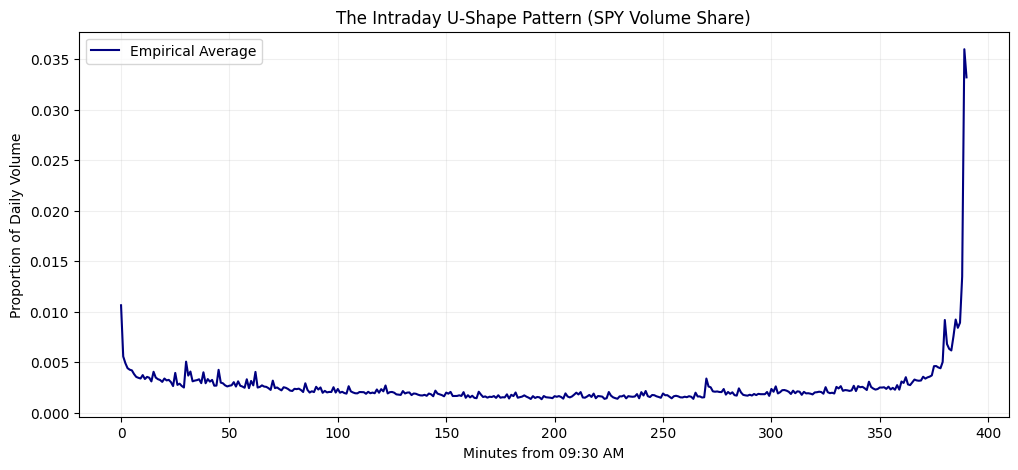

In [2]:
# Compute the empirical average profile
avg_profile = df_rth.groupby('minute_of_day')['vol_proportion'].mean().sort_index()

plt.figure(figsize=(12, 5))
avg_profile.plot(color='navy', label='Empirical Average')
plt.title('The Intraday U-Shape Pattern (SPY Volume Share)')
plt.xlabel('Minutes from 09:30 AM')
plt.ylabel('Proportion of Daily Volume')
plt.grid(alpha=0.2)
plt.legend()
plt.show()

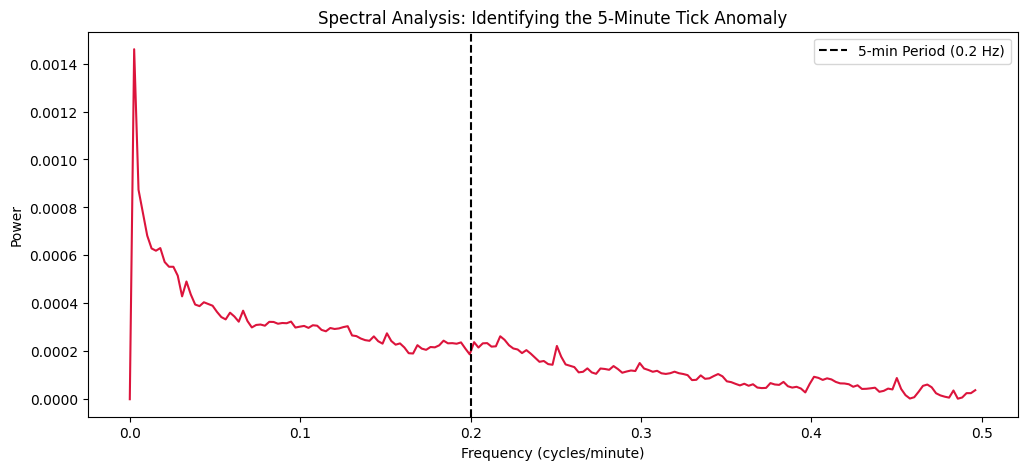

In [3]:
# Perform FFT Fast Fourier Transform on the average profile to find periodicities
y = avg_profile.values
N = len(y)
yf = fft(y - np.mean(y)) # De-mean to remove DC component
xf = fftfreq(N, 1)

plt.figure(figsize=(12, 5))
plt.plot(xf[:N//2], 2.0/N * np.abs(yf[:N//2]), color='crimson')
plt.axvline(x=0.2, color='black', linestyle='--', label='5-min Period (0.2 Hz)')
plt.title('Spectral Analysis: Identifying the 5-Minute Tick Anomaly')
plt.xlabel('Frequency (cycles/minute)')
plt.ylabel('Power')
plt.legend()
plt.show()

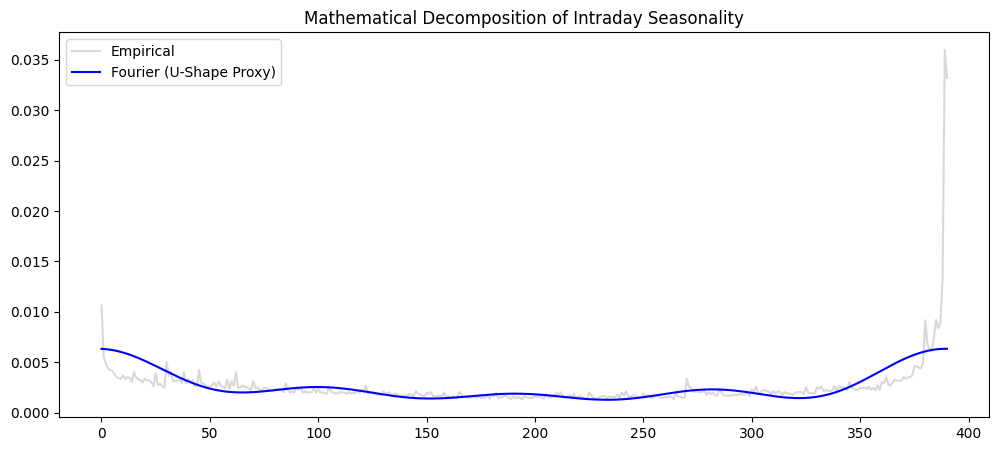

In [4]:
# Advanced Seasonality Modelling (Fourier & Splines)
# To provide the machine learning model with a "structural expectation," we fit mathematical curves to the U-shape.

# Fourier Baseline: Captures periodic cycles.

# Cubic Spline: Captures the smooth "lull" and "surge" curve.

    
    
x_mins = avg_profile.index.values
y_vals = avg_profile.values

# 1. Cubic Spline
cs = CubicSpline(x_mins, y_vals)
df_rth['baseline_spline'] = cs(df_rth['minute_of_day'])

# 2. Fourier Smoothing (Top 5 harmonics)
y_fft = fft(y_vals)
y_fft_filtered = np.zeros_like(y_fft)
harmonics = 5 
y_fft_filtered[:harmonics] = y_fft[:harmonics]
y_fft_filtered[-harmonics+1:] = y_fft[-harmonics+1:]
f_smooth = np.real(ifft(y_fft_filtered))
df_rth['baseline_fourier'] = df_rth['minute_of_day'].map(pd.Series(f_smooth, index=x_mins))

plt.figure(figsize=(12, 5))
plt.plot(x_mins, y_vals, alpha=0.3, color='gray', label='Empirical')
plt.plot(x_mins, f_smooth, color='blue', label='Fourier (U-Shape Proxy)')
plt.title('Mathematical Decomposition of Intraday Seasonality')
plt.legend()
plt.show()

In [5]:
# Feature Engineering for Machine Learning
# We incorporate market microstructure features:

# Overnight Return: Large price gaps drive morning volume.

# Tick Dummies: Binary flags for the 5-minute and top-of-hour marks.

# Volatility: Rolling spread proxy.


# 1. Tick Anomaly Features
df_rth['is_5min_tick'] = (df_rth['timestamp'].dt.minute % 5 == 0).astype(int)
df_rth['is_top_hour'] = (df_rth['timestamp'].dt.minute == 0).astype(int)

# 2. Microstructure context (Overnight Shock)
full_df = df.set_index('timestamp')
daily_close = full_df.between_time('15:59', '16:00').groupby(full_df.between_time('15:59', '16:00').index.date)['close'].last()
daily_open = full_df.between_time('09:30', '09:31').groupby(full_df.between_time('09:30', '09:31').index.date)['open'].first()
overnight_ret = (daily_open - daily_close.shift(1)) / daily_close.shift(1)
df_rth = df_rth.merge(overnight_ret.rename('overnight_ret'), left_on='date', right_index=True, how='left')

# 3. Volatility Proxy
df_rth['log_ret'] = np.log(df_rth['close'] / df_rth['close'].shift(1))
df_rth['rolling_vol'] = df_rth['log_ret'].rolling(10).std()

df_ml = df_rth.dropna()

In [6]:
# Model Training and Out-of-Sample Evaluation
# We use a Time-Series Split (no shuffling) to train a Gradient Boosting model. This mimics a real trading 
# environment where we predict future volume based on historical patterns.


features = [
    'minute_of_day', 'baseline_fourier', 'is_5min_tick', 
    'is_top_hour', 'overnight_ret', 'rolling_vol'
]
target = 'vol_proportion'

# Split (80% train, 20% test)
split_idx = int(len(df_ml) * 0.8)
train, test = df_ml.iloc[:split_idx], df_ml.iloc[split_idx:]

# Train Model
model = GradientBoostingRegressor(n_estimators=100, max_depth=5, learning_rate=0.1)
model.fit(train[features], train[target])

# Predictions
preds = model.predict(test[features])
print(f"MAE: {mean_absolute_error(test[target], preds):.6f}")
print(f"R2 Score: {r2_score(test[target], preds):.4f}")

MAE: 0.000885
R2 Score: 0.7233


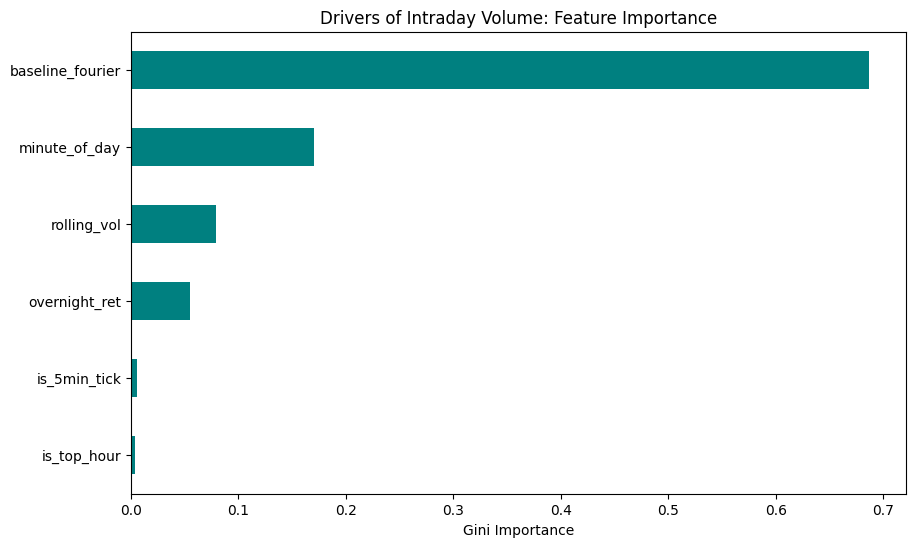

In [7]:
# Feature Importance and Conclusion
# the "drivers" of the model.

importance = pd.Series(model.feature_importances_, index=features).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
importance.plot(kind='barh', color='teal')
plt.title('Drivers of Intraday Volume: Feature Importance')
plt.xlabel('Gini Importance')
plt.show()

In [8]:
# # 2. IDENTIFYING THE U-SHAPE PATTERN
# # We calculate the average volume for every minute of the trading day.
# u_shape = df_rth.groupby('minute_of_day')['volume'].mean()

# plt.figure(figsize=(12, 5))
# plt.plot(u_shape.index, u_shape.values, color='teal', label='Avg Volume')
# plt.title('Intraday Volume Profile: The U-Shape Pattern', fontsize=14)
# plt.xlabel('Minutes from Midnight')
# plt.ylabel('Average Volume')
# plt.axvspan(570, 600, color='gray', alpha=0.2, label='Market Open')
# plt.axvspan(930, 960, color='gray', alpha=0.2, label='Market Close')
# plt.legend()
# plt.grid(True, alpha=0.3)
# plt.show()



In [9]:
# # 3. IDENTIFYING THE 5-MINUTE TICK PATTERN
# # Many algorithms trigger at 5-min intervals (e.g., 10:00, 10:05).
# # We check for "seasonality" within the hour.
# df_rth['min_in_hour'] = df_rth['timestamp'].dt.minute
# tick_pattern = df_rth.groupby('min_in_hour')['volume'].mean()

# plt.figure(figsize=(12, 5))
# tick_pattern.plot(kind='bar', color='orange')
# plt.title('5-Minute Tick Pattern: Volume Spikes on 5-min Intervals', fontsize=14)
# plt.xlabel('Minute of the Hour')
# plt.ylabel('Avg Volume')
# plt.xticks(np.arange(0, 61, 5))
# plt.grid(axis='y', alpha=0.3)
# plt.show()



In [10]:
# # 4. MACHINE LEARNING: CLUSTERING DAILY PROFILES
# # Master's Level: Cluster days to identify "Volume Regimes"
# # Pivot data: Rows = Dates, Columns = Minutes, Values = Normalized Volume
# daily_profiles = df_rth.pivot(index='date', columns='minute_of_day', values='volume').dropna()

# # Normalize: volume at time t / total day volume (focuses on 'shape' not 'magnitude')
# daily_profiles_norm = daily_profiles.div(daily_profiles.sum(axis=1), axis=0)

# # Apply K-Means to find 3 types of intraday patterns
# kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
# clusters = kmeans.fit_predict(daily_profiles_norm)

# # Visualize the 3 distinct U-shape regimes
# plt.figure(figsize=(12, 6))
# colors = ['red', 'blue', 'green']
# for i in range(3):
#     cluster_mean = daily_profiles_norm[clusters == i].mean()
#     plt.plot(cluster_mean.index, cluster_mean.values, label=f'Regime {i}', color=colors[i])

# plt.title('Clustered Volume Regimes (Varying U-Shapes)', fontsize=14)
# plt.xlabel('Minute of Day')
# plt.ylabel('Relative Volume')
# plt.legend()
# plt.show()

# # 5. PREDICTIVE MODELING: FORECASTING 5-MIN VOLUME
# # Resample to 5-minute ticks for prediction
# resample_logic = {'volume': 'sum', 'high': 'max', 'low': 'min', 'close': 'last'}
# df_5m = df_rth.set_index('timestamp').resample('5min').apply(resample_logic).dropna()

# # Feature Engineering
# df_5m['lag_1'] = df_5m['volume'].shift(1)
# df_5m['lag_2'] = df_5m['volume'].shift(2)
# df_5m['volatility'] = (df_5m['high'] - df_5m['low']) / df_5m['close']
# df_5m['hour'] = df_5m.index.hour
# df_5m['minute'] = df_5m.index.minute
# df_5m = df_5m.dropna()

# # Split and Train
# X = df_5m[['lag_1', 'lag_2', 'volatility', 'hour', 'minute']]
# y = df_5m['volume']

# split = int(len(df_5m) * 0.8)
# X_train, X_test = X[:split], X[split:]
# y_train, y_test = y[:split], y[split:]

# model = XGBRegressor(n_estimators=100, learning_rate=0.05)
# model.fit(X_train, y_train)

# # Evaluation
# preds = model.predict(X_test)
# mae = mean_absolute_error(y_test, preds)
# print(f"Mean Absolute Error for 5-min Volume Prediction: {mae:.2f}")

# # Plot Prediction vs Reality
# plt.figure(figsize=(12, 5))
# plt.plot(y_test.values[:100], label='Actual', alpha=0.7)
# plt.plot(preds[:100], label='Predicted', alpha=0.7)
# plt.title('5-Minute Volume Prediction (XGBoost)')
# plt.legend()
# plt.show()